In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

# Load & prepare data

In [5]:
symbols = ["BTC", "ETH", "XRP"]

data_dict = {}
for symbol in symbols:
    train = pd.read_parquet(f"../../data/train_{symbol}_1d_2020-01-01_2024-04-01.parquet")
    val = pd.read_parquet(f"../../data/val_{symbol}_1d_2024-04-01_2025-04-01.parquet")
    test = pd.read_parquet(f"../../data/test_{symbol}_1d_2025-04-01_2026-04-01.parquet")

    data = pd.concat([train, val, test])
    data['timestamp'] = pd.to_datetime(data['timestamp'], unit='ms')
    data["cum_return"] = ((1 + data["open"].pct_change()).cumprod() - 1)

    data_dict[symbol] = data

# Plot

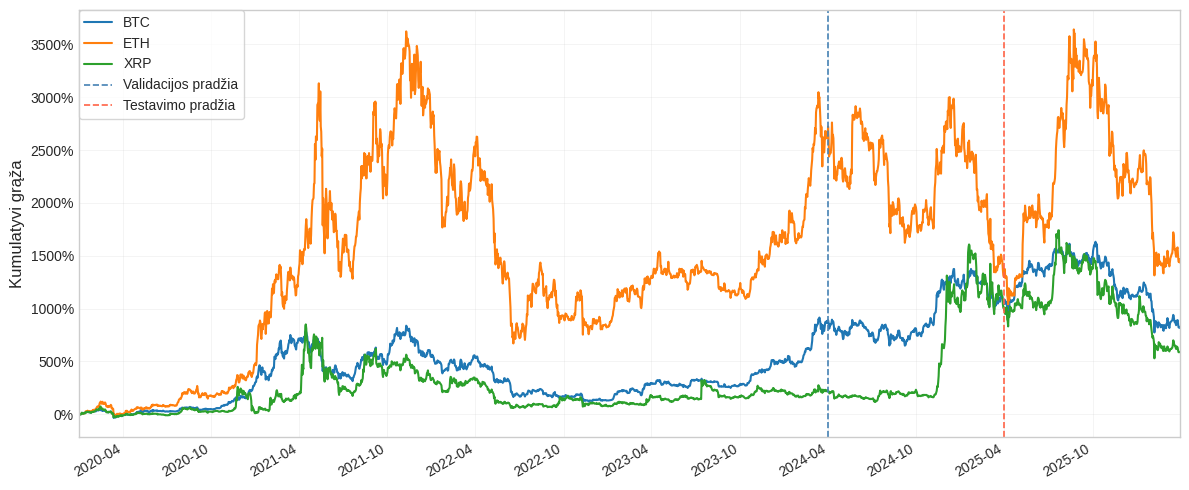

In [6]:
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(12, 5))

colors = plt.cm.tab10.colors
for i, symbol in enumerate(symbols):
    data = data_dict[symbol]
    ax.plot(
        data['timestamp'],
        data['cum_return'],
        label=symbol,
        linewidth=1.5,
        color=colors[i % len(colors)]
    )

ax.axvline(
    pd.to_datetime("2024-04-01"),
    color="steelblue", ls="--", linewidth=1.2, label="Validacijos pradžia"
)
ax.axvline(
    pd.to_datetime("2025-04-01"),
    color="tomato", ls="--", linewidth=1.2, label="Testavimo pradžia"
)

ax.set_ylabel("Kumulatyvi grąža", fontsize=12)

ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=0))

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
fig.autofmt_xdate(rotation=30, ha="right")

first_data = next(iter(data_dict.values()))
ax.set_xlim(first_data["timestamp"].min(), first_data["timestamp"].max())

ax.legend(
    borderaxespad=0,
    fontsize=10,
    frameon=True
)

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("cum_grazos.png", dpi=300, bbox_inches="tight")